In [1]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [114]:
import os
import json
import pandas as pd
import re
from pathlib import Path

def collect_results_json_recursive(root_dir='re-pro-motivation'):
    # Dictionary to store all the extracted data
    all_data = []
    
    # Regex pattern to extract region and function from R1-49-output format
    region_function_pattern = r'R(\d+)-(\d+)-output'
    
    # Walk through all directories and subdirectories
    for dirpath, dirnames, filenames in os.walk(root_dir):
        if 'results.json' in filenames:
            json_path = os.path.join(dirpath, 'results.json')
            
            # Parse the path components
            path_parts = Path(dirpath).parts
            
            # Initialize variables to store extracted information
            region = None
            function = None
            infrastructure = None
            approach = None
            experiment = None
            repetition = None
            week = None
            proactive_approach = 'reactive'
            
            # Extract information from path components
            for i, part in enumerate(path_parts):
                # Extract region and function
                region_function_match = re.match(region_function_pattern, part)
                if region_function_match:
                    region = f"R{region_function_match.group(1)}"
                    function = region_function_match.group(2)
                
                # Extract infrastructure
                if part.startswith('infra-'):
                    infrastructure = part
                
                # Extract approach
                if part.startswith('results-'):
                    approach = part.replace('results-', '')

                # Extract proactive approach
                if part == 'first_second':
                    proactive_approach = 'first_second'
                elif part == 'first':
                    proactive_approach = 'first'
                elif part == 'one_day':
                    proactive_approach = 'one_day'
                elif part == 'first_second_third':
                    proactive_approach = 'first_second_third'
                
                # Extract experiment (timestamp)
                if re.match(r'\d{8}-\d{6}-\d{6}', part):
                    experiment = part
                
                # Extract repetition and week
                if experiment and i < len(path_parts) - 1:
                    if path_parts[i] == experiment and i + 1 < len(path_parts):
                        repetition = path_parts[i+1]
                    if path_parts[i] == experiment and i + 2 < len(path_parts):
                        week = path_parts[i+2]
            
            try:
                # Read the JSON file
                with open(json_path, 'r') as f:
                    results_data = json.load(f)
                
                # Create a dictionary with path information and results data
                entry = {
                    'region': region,
                    'function': function,
                    'infrastructure': infrastructure,
                    'approach': approach,
                    'proactive_approach': proactive_approach,
                    'experiment': experiment,
                    'repetition': repetition,
                    'week': week
                }
                
                # Add all the keys and values from results.json
                for key, value in results_data.items():
                    entry[key] = value
                
                all_data.append(entry)
                
            except json.JSONDecodeError:
                print(f"Error decoding JSON in {json_path}")
            except Exception as e:
                print(f"Error reading {json_path}: {e}")
    
    # Create a DataFrame from all collected data
    if all_data:
        df = pd.DataFrame(all_data)
    else:
        df = pd.DataFrame()
    
    return df

# Example usage
if __name__ == "__main__":
    results_df = collect_results_json_recursive("re-pro-motivation-dnn2")
    print(results_df)
    
    # Optionally save to CSV
    # results_df.to_csv('combined_results.csv')


    region function infrastructure   approach proactive_approach  \
0       R1      351        infra-1  proactive       first_second   
1       R1      351        infra-1  proactive       first_second   
2       R1      351        infra-1  proactive       first_second   
3       R1      351        infra-1  proactive       first_second   
4       R1      351        infra-1   reactive           reactive   
..     ...      ...            ...        ...                ...   
158     R1     1412        infra-1  proactive              first   
159     R1     1412        infra-1  proactive            one_day   
160     R1     1412        infra-1  proactive            one_day   
161     R1     1412        infra-1  proactive            one_day   
162     R1     1412        infra-1  proactive            one_day   

                 experiment repetition week  averageQueueTime  \
0    20250316-131904-497669          0    3         53.581813   
1    20250316-131904-497669          0    2         7

In [115]:
compare_df = results_df[results_df['function'] != '1465']

Text(0.5, 0, 'Function')

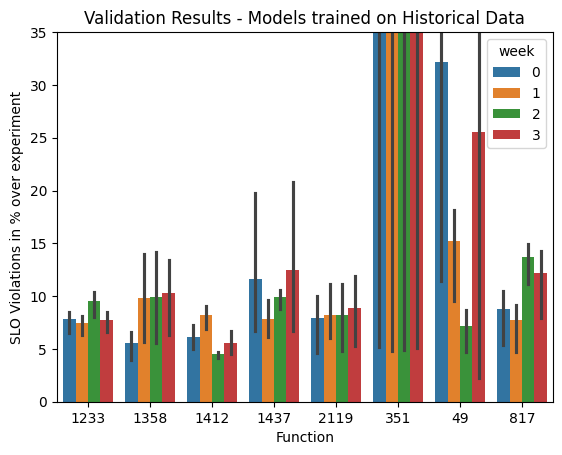

In [116]:
g = sns.barplot(x='function', y='penaltyProportion', hue='week', data=compare_df[compare_df['approach'] == 'proactive'].sort_values(by=['function','week']))
g.set_ylim(0,35)
g.set_title('Validation Results - Models trained on Historical Data')
g.set_ylabel('SLO Violations in % over experiment')
g.set_xlabel('Function')

Text(0.5, 0, 'Function')

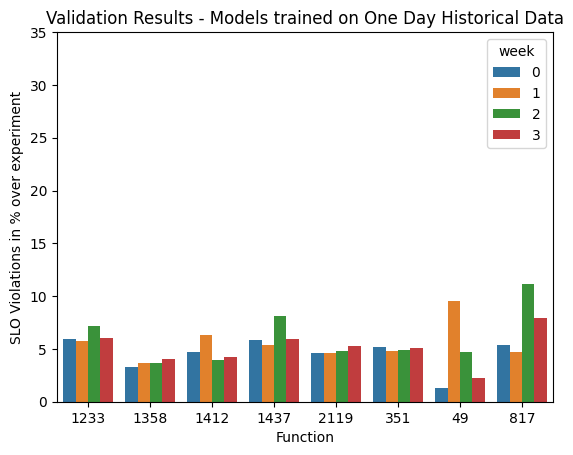

In [117]:
g = sns.barplot(x='function', y='penaltyProportion', hue='week', data=compare_df[compare_df['proactive_approach'] == 'one_day'].sort_values(by=['function','week']))
g.set_ylim(0,35)
g.set_title('Validation Results - Models trained on One Day Historical Data')
g.set_ylabel('SLO Violations in % over experiment')
g.set_xlabel('Function')

Text(0.5, 0, 'Function')

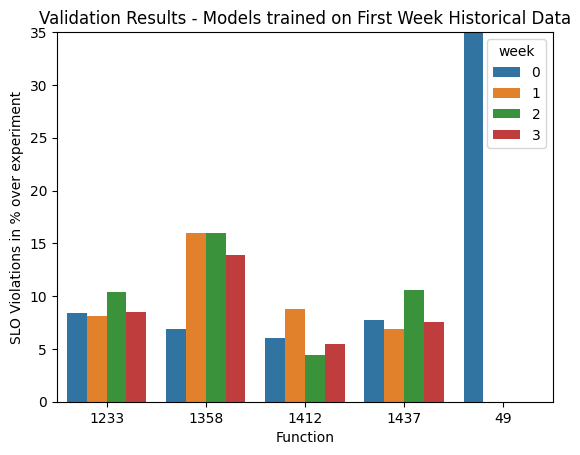

In [118]:
g = sns.barplot(x='function', y='penaltyProportion', hue='week', data=compare_df[compare_df['proactive_approach'] == 'first'].sort_values(by=['function','week']))
g.set_ylim(0,35)
g.set_title('Validation Results - Models trained on First Week Historical Data')
g.set_ylabel('SLO Violations in % over experiment')
g.set_xlabel('Function')

Text(0.5, 0, 'Function')

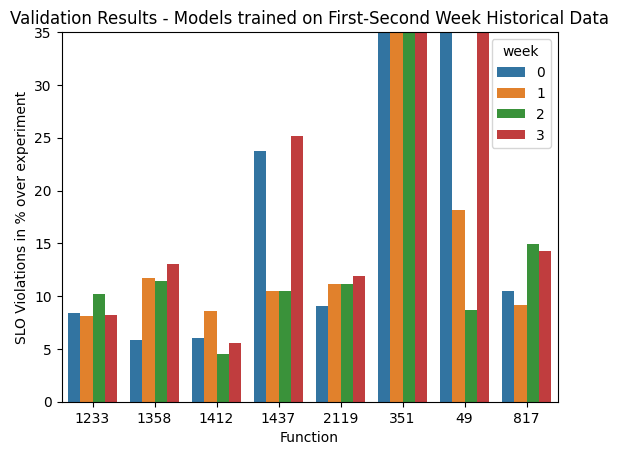

In [119]:
g = sns.barplot(x='function', y='penaltyProportion', hue='week', data=compare_df[compare_df['proactive_approach'] == 'first_second'].sort_values(by=['function','week']))
g.set_ylim(0,35)
g.set_title('Validation Results - Models trained on First-Second Week Historical Data')
g.set_ylabel('SLO Violations in % over experiment')
g.set_xlabel('Function')

Text(0.5, 0, 'Function')

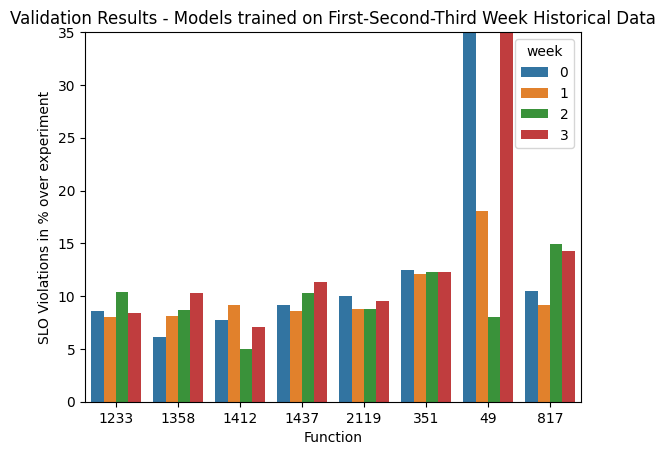

In [120]:
g = sns.barplot(x='function', y='penaltyProportion', hue='week', data=compare_df[compare_df['proactive_approach'] == 'first_second_third'].sort_values(by=['function','week']))
g.set_ylim(0,35)
g.set_title('Validation Results - Models trained on First-Second-Third Week Historical Data')
g.set_ylabel('SLO Violations in % over experiment')
g.set_xlabel('Function')

In [92]:
compare_df[compare_df['proactive_approach'] == 'one_day'].groupby('week')['penaltyProportion'].describe()

,count,mean,std,min,25%,50%,75%,max
week,,,,,,,,
0,8.0,14.434225,26.084368,4.405798,4.685798,5.476506,5.836801,78.973715
1,8.0,7.174968,5.015301,4.650958,5.170528,5.489708,5.881214,19.522264
2,8.0,6.736209,2.535333,3.941300,4.940864,6.730114,7.109997,12.171148
3,8.0,12.924816,19.177253,3.998520,5.243410,5.816139,8.009122,60.196036


In [88]:
compare_df[compare_df['approach'] == 'proactive'].groupby(['week'])['penaltyProportion'].describe()

,count,mean,std,min,25%,50%,75%,max
week,,,,,,,,
0,32.0,18.318950,28.571899,1.330356,5.216028,6.695509,12.508649,100.0
1,32.0,17.762632,26.627398,4.650958,6.126820,8.155419,13.052553,100.0
2,32.0,17.486010,26.603371,3.941300,6.513220,8.781112,13.649536,100.0
3,32.0,21.261263,28.106014,2.340089,6.148136,11.157417,13.193719,100.0


Text(0.5, 0, 'Function')

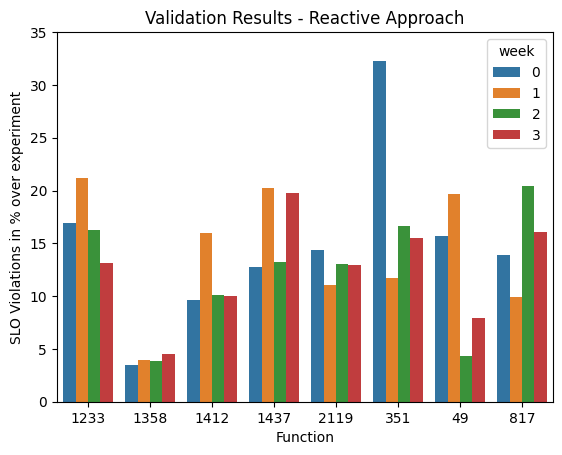

In [86]:
g = sns.barplot(x='function', y='penaltyProportion', hue='week', data=compare_df[compare_df['approach'] == 'reactive'].sort_values(by=['function','week']))
g.set_ylim(0,35)
g.set_title('Validation Results - Reactive Approach')
g.set_ylabel('SLO Violations in % over experiment')
g.set_xlabel('Function')

In [87]:
compare_df[compare_df['approach'] == 'reactive'].groupby(['week'])['penaltyProportion'].describe()

,count,mean,std,min,25%,50%,75%,max
week,,,,,,,,
0,8.0,14.892499,8.201615,3.463660,12.018102,14.159793,15.991775,32.293595
1,8.0,14.217034,6.072971,3.926087,10.767533,13.860736,19.832403,21.191049
2,8.0,12.235312,5.866166,3.887132,8.664578,13.110908,16.371168,20.388926
3,8.0,12.490443,4.887427,4.480009,9.504216,13.038258,15.647763,19.811738


In [57]:
third_four_df = results_df[results_df['week'] != '0']
third_four_df = third_four_df[third_four_df['week'] != '1']

In [58]:
third_four_df

,region,function,infrastructure,approach,proactive_approach,experiment,repetition,week,averageQueueTime,penaltyProportion,averageExecutionTime,averageComputerTime,averageWaitTime,endTime
0,R1,351,infra-1,proactive,first_second,20250313-233644-327582,0,3,15.231233,94.371223,0.001048,0.022125,0.0,1201.248432
1,R1,351,infra-1,proactive,first_second,20250313-233644-327582,0,2,64.180616,100.000000,0.004085,0.025163,0.0,1291.636863
4,R1,351,infra-1,reactive,reactive,20250313-225454-461915,0,3,1.572356,15.500429,0.002838,0.021797,0.0,1203.799832
5,R1,351,infra-1,reactive,reactive,20250313-225454-461915,0,2,1.517106,16.682992,0.002222,0.021723,0.0,1201.127488
8,R1,351,infra-1,proactive,first_second_third,20250313-234948-512825,0,3,15.231233,94.371223,0.001048,0.022125,0.0,1201.248432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,R1,1412,infra-1,proactive,first_second_third,20250313-234512-287134,0,2,1.004071,4.956620,0.006825,0.027903,0.0,1199.977491
172,R1,1412,infra-1,proactive,first,20250313-231828-594604,0,3,1.209511,6.549843,0.003902,0.024980,0.0,1199.977312
173,R1,1412,infra-1,proactive,first,20250313-231828-594604,0,2,0.932312,4.872635,0.001048,0.022125,0.0,1199.948168
176,R1,1412,infra-1,proactive,one_day,20250313-230432-107459,0,3,0.979436,3.998520,0.001192,0.022254,0.0,1199.946274


<Axes: xlabel='function', ylabel='penaltyProportion'>

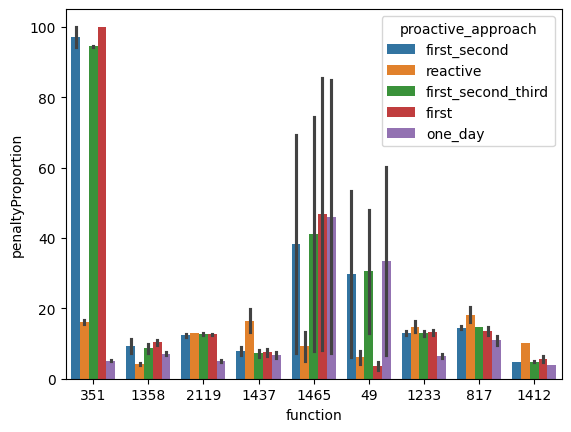

In [59]:
sns.barplot(x='function', y='penaltyProportion', hue='proactive_approach', data=third_four_df)

<Axes: xlabel='function', ylabel='penaltyProportion'>

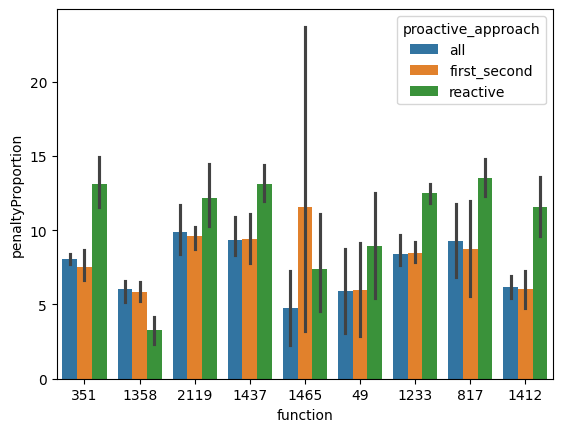

In [8]:
sns.barplot(x='function', y='penaltyProportion', hue='proactive_approach', data=results_df)

<Axes: xlabel='function', ylabel='penaltyProportion'>

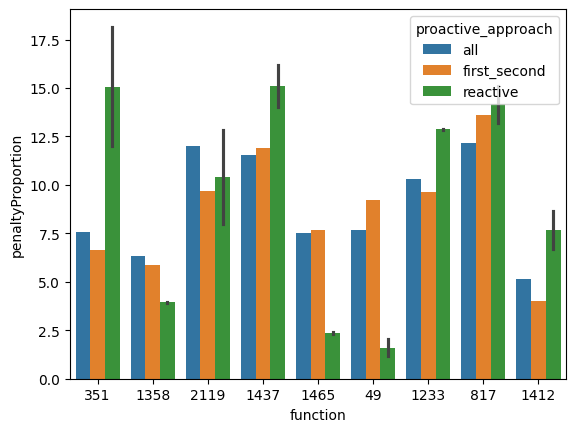

In [10]:
sns.barplot(x='function', y='penaltyProportion', hue='proactive_approach', data=third_four_df[third_four_df['week'] == '2'])

<Axes: xlabel='function', ylabel='penaltyProportion'>

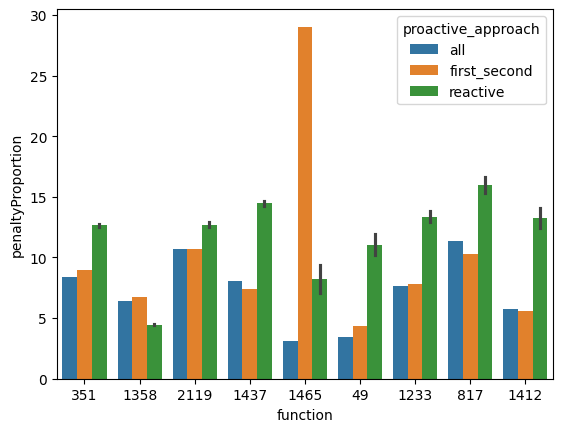

In [12]:
sns.barplot(x='function', y='penaltyProportion', hue='proactive_approach', data=third_four_df[third_four_df['week'] == '3'])

<Axes: xlabel='function', ylabel='penaltyProportion'>

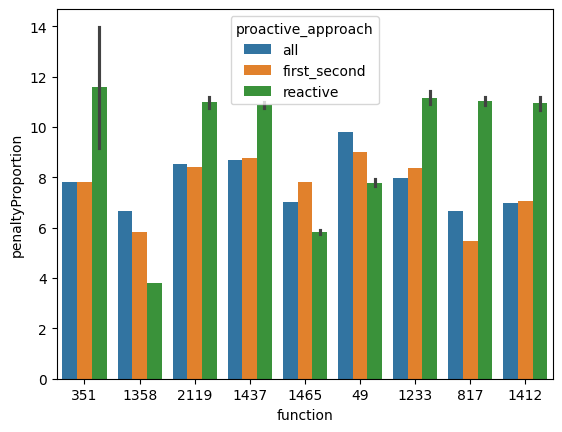

In [13]:
sns.barplot(x='function', y='penaltyProportion', hue='proactive_approach', data=results_df[results_df['week'] == '1'])

<Axes: xlabel='function', ylabel='penaltyProportion'>

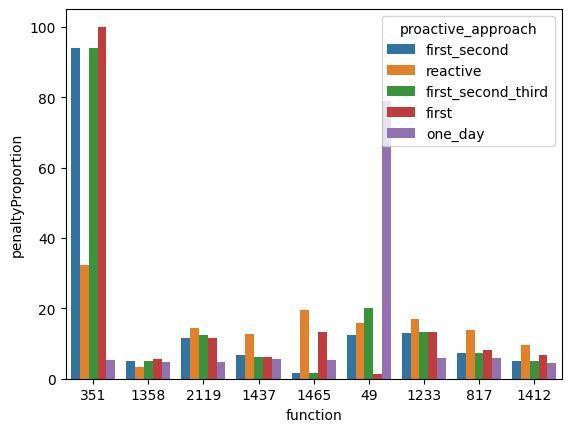

In [65]:
sns.barplot(x='function', y='penaltyProportion', hue='proactive_approach', data=results_df[results_df['week'] == '0'])

<Axes: xlabel='week', ylabel='penaltyProportion'>

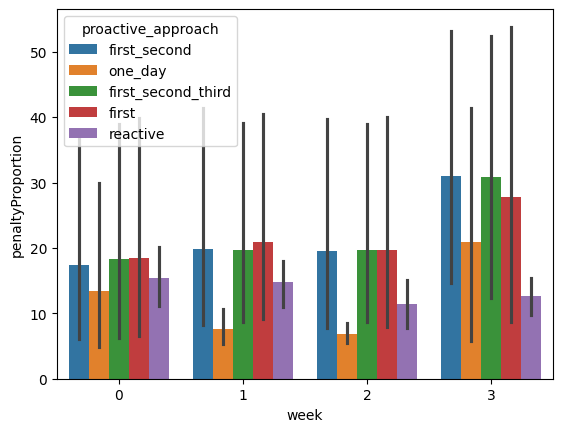

In [66]:
sns.barplot(x='week', y='penaltyProportion', hue='proactive_approach', data=results_df.sort_values(by='week'))
# plt.savefig('first_second_all_impact.pdf')

In [23]:
a=  '/home/philipp/herosim/my-herosim/re-pro-motivation/R1-1233-output/infra-1/results-reactive/20250310-152458-397071/0/0/penalty_over_time.csv'
b = '/home/philipp/herosim/my-herosim/re-pro-motivation/R1-1233-output/all/infra-1/results-proactive/R1-1233-origin-1-target-1/20250310-161118-666001/0/0/penalty_over_time.csv'
df = pd.read_csv(a)
df

,Unnamed: 0,time,penalty
0,0,0.000000,1.000000
1,1,0.013336,1.000000
2,2,0.016550,1.000000
3,3,0.027486,1.000000
4,4,0.033484,1.000000
...,...,...,...
18007,18007,1199.901629,0.121856
18008,18008,1199.925154,0.121862
18009,18009,1199.941241,0.121868
18010,18010,1199.953886,0.121874


<Axes: xlabel='time', ylabel='penalty'>

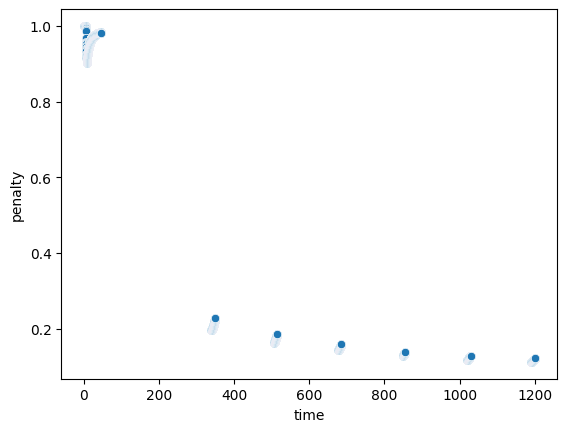

In [24]:
sns.scatterplot(x='time', y='penalty', data=df)

In [63]:
# For a more detailed analysis including other factors
detailed_df =  results_df[results_df['proactive_approach'] != 'all']
detailed_df = detailed_df.groupby(['week', 'region', 'function', 'infrastructure', 'approach', 'proactive_approach'])['penaltyProportion'].mean().reset_index()

# Create a function to calculate percentage change for each group
def calculate_percentage_change(group):
    if len(group) != 2 or not {'reactive', 'proactive'}.issubset(group['approach'].values):
        return group  # Return unchanged if we don't have both approaches
    
    reactive_val = group.loc[group['approach'] == 'reactive', 'penaltyProportion'].values[0]
    proactive_val = group.loc[group['approach'] == 'proactive', 'penaltyProportion'].values[0]
    
    # Add percentage change to both rows
    group['percentage_change'] = ((proactive_val - reactive_val) / reactive_val * 100)
    return group

# Apply the function to each group
result_df = detailed_df.groupby(['week', 'region', 'function', 'infrastructure']).apply(calculate_percentage_change).reset_index(drop=True)

# Display the results
print(result_df)


    week region function infrastructure   approach  proactive_approach  \
0      0     R1     1233        infra-1  proactive               first   
1      0     R1     1233        infra-1  proactive        first_second   
2      0     R1     1233        infra-1  proactive  first_second_third   
3      0     R1     1233        infra-1  proactive             one_day   
4      0     R1     1233        infra-1   reactive            reactive   
..   ...    ...      ...            ...        ...                 ...   
175    3     R1      817        infra-1  proactive               first   
176    3     R1      817        infra-1  proactive        first_second   
177    3     R1      817        infra-1  proactive  first_second_third   
178    3     R1      817        infra-1  proactive             one_day   
179    3     R1      817        infra-1   reactive            reactive   

     penaltyProportion  
0            13.242129  
1            12.873001  
2            13.289138  
3          

/tmp/ipykernel_9758/2779211474.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result_df = detailed_df.groupby(['week', 'region', 'function', 'infrastructure']).apply(calculate_percentage_change).reset_index(drop=True)


In [64]:
third_four_week = result_df[result_df['week'] != '0']
third_four_week = third_four_week[third_four_week['week'] != '1']
g = sns.boxplot(x='function', y='percentage_change', hue='proactive_approach', data=result_df)
# g.set_yscale("symlog")
plt.savefig('percentage_change_reactive.pdf')

ValueError: Could not interpret value `percentage_change` for `y`. An entry with this name does not appear in `data`.

In [121]:
import os
import pandas as pd
import re
from pathlib import Path

def collect_system_events_csv_recursive(root_dir='re-pro-motivation'):
    # Dictionary to store all the extracted data
    all_data = []
    
    # Regex pattern to extract region and function from R1-49-output format
    region_function_pattern = r'R(\d+)-(\d+)-output'
    
    # Walk through all directories and subdirectories
    for dirpath, dirnames, filenames in os.walk(root_dir):
        if 'system_events.csv' in filenames:
            csv_path = os.path.join(dirpath, 'system_events.csv')
            
            # Parse the path components
            path_parts = Path(dirpath).parts
            
            # Initialize variables to store extracted information
            region = None
            function = None
            infrastructure = None
            approach = None
            experiment = None
            repetition = None
            week = None
            proactive_approach = 'reactive'
            # Extract information from path components
            for i, part in enumerate(path_parts):
                # Extract region and function
                region_function_match = re.match(region_function_pattern, part)
                if region_function_match:
                    region = f"R{region_function_match.group(1)}"
                    function = region_function_match.group(2)
                
                # Extract infrastructure
                if part.startswith('infra-'):
                    infrastructure = part
                
                # Extract approach
                if part.startswith('results-'):
                    approach = part.replace('results-', '')
                
                # Extract experiment (timestamp)
                if re.match(r'\d{8}-\d{6}-\d{6}', part):
                    experiment = part

                                # Extract proactive approach
                if part == 'first_second':
                    proactive_approach = 'first_second'
                elif part == 'first':
                    proactive_approach = 'first'
                elif part == 'one_day':
                    proactive_approach = 'one_day'
                elif part == 'first_second_third':
                    proactive_approach = 'first_second_third'
                
                # Extract repetition and week
                if experiment and i < len(path_parts) - 1:
                    if path_parts[i] == experiment and i + 1 < len(path_parts):
                        repetition = path_parts[i+1]
                    if path_parts[i] == experiment and i + 2 < len(path_parts):
                        week = path_parts[i+2]
            
            try:
                # Read the CSV file
                events_df = pd.read_csv(csv_path)
                
                # Calculate average values
                avg_count = events_df['count'].mean()
                avg_queue_length = events_df['average_queue_length'].mean()
                
                # Create a dictionary with path information and calculated averages
                entry = {
                    'region': region,
                    'function': function,
                    'infrastructure': infrastructure,
                    'proactive_approach': proactive_approach,
                    'approach': approach,
                    'experiment': experiment,
                    'repetition': repetition,
                    'week': week,
                    'avg_count': avg_count,
                    'avg_queue_length': avg_queue_length
                }
                
                all_data.append(entry)
                
            except pd.errors.EmptyDataError:
                print(f"Empty CSV file: {csv_path}")
            except Exception as e:
                print(f"Error reading {csv_path}: {e}")
    
    # Create a DataFrame from all collected data
    if all_data:
        df = pd.DataFrame(all_data)
    else:
        df = pd.DataFrame()
    
    return df

# Example usage
if __name__ == "__main__":
    system_events_df = collect_system_events_csv_recursive("re-pro-motivation-dnn2")
    print(system_events_df)
    
    # Calculate the percentage change between reactive and proactive approaches
    # First, group by relevant factors and approach
    grouped_df = system_events_df.groupby(['week', 'region', 'function', 'infrastructure', 'approach'])[['avg_count', 'avg_queue_length']].mean().reset_index()
    
    # Pivot to get reactive and proactive side by side
    pivot_count = grouped_df.pivot_table(
        index=['week', 'region', 'function', 'infrastructure'],
        columns='approach',
        values='avg_count'
    ).reset_index()
    
    pivot_queue = grouped_df.pivot_table(
        index=['week', 'region', 'function', 'infrastructure'],
        columns='approach',
        values='avg_queue_length'
    ).reset_index()
    
    # Calculate percentage change (negative values indicate reduction compared to reactive)
    if 'reactive' in pivot_count.columns and 'proactive' in pivot_count.columns:
        pivot_count['count_percentage_change'] = ((pivot_count['proactive'] - pivot_count['reactive']) / 
                                                 pivot_count['reactive'] * 100)
    
    if 'reactive' in pivot_queue.columns and 'proactive' in pivot_queue.columns:
        pivot_queue['queue_percentage_change'] = ((pivot_queue['proactive'] - pivot_queue['reactive']) / 
                                                 pivot_queue['reactive'] * 100)
    
    # Merge the results
    result_df = pd.merge(
        pivot_count, 
        pivot_queue[['week', 'region', 'function', 'infrastructure', 'queue_percentage_change']],
        on=['week', 'region', 'function', 'infrastructure']
    )
    
    print("\nPercentage Change Analysis:")
    print(result_df)
    
    # Optionally save to CSV
    # system_events_df.to_csv('system_events_summary.csv', index=False)
    # result_df.to_csv('system_events_percentage_change.csv', index=False)


    region function infrastructure proactive_approach   approach  \
0       R1      351        infra-1       first_second  proactive   
1       R1      351        infra-1       first_second  proactive   
2       R1      351        infra-1       first_second  proactive   
3       R1      351        infra-1       first_second  proactive   
4       R1      351        infra-1           reactive   reactive   
..     ...      ...            ...                ...        ...   
158     R1     1412        infra-1              first  proactive   
159     R1     1412        infra-1            one_day  proactive   
160     R1     1412        infra-1            one_day  proactive   
161     R1     1412        infra-1            one_day  proactive   
162     R1     1412        infra-1            one_day  proactive   

                 experiment repetition week  avg_count  avg_queue_length  
0    20250316-131904-497669          0    3    7.00000       1154.101045  
1    20250316-131904-497669      

In [108]:
system_events_df

,region,function,infrastructure,proactive_approach,approach,experiment,repetition,week,avg_count,avg_queue_length
0,R1,351,infra-1,first_second,proactive,20250313-233644-327582,0,3,4.000000,580.364198
1,R1,351,infra-1,first_second,proactive,20250313-233644-327582,0,2,4.000000,2384.660920
2,R1,351,infra-1,first_second,proactive,20250313-233644-327582,0,0,4.000000,635.830247
3,R1,351,infra-1,first_second,proactive,20250313-233644-327582,0,1,4.000000,1852.008621
4,R1,351,infra-1,reactive,reactive,20250313-225454-461915,0,3,11.709544,10.971139
...,...,...,...,...,...,...,...,...,...,...
175,R1,1412,infra-1,first,proactive,20250313-231828-594604,0,1,12.000000,23.387500
176,R1,1412,infra-1,one_day,proactive,20250313-230432-107459,0,3,44.000000,3.788068
177,R1,1412,infra-1,one_day,proactive,20250313-230432-107459,0,2,44.000000,2.435227
178,R1,1412,infra-1,one_day,proactive,20250313-230432-107459,0,0,44.000000,4.075852


Text(0, 0.5, 'Average Running Function Instances')

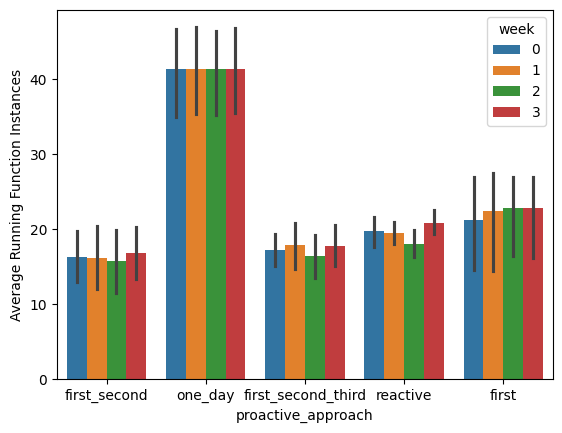

In [122]:
g = sns.barplot(x='proactive_approach', y='avg_count', hue='week', data=system_events_df.sort_values(by='week'))
g.set_ylabel("Average Running Function Instances")